# Prophet : model experiment


In [ ]:

import importlib.util, os, subprocess, sys
from pathlib import Path

IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/ML_FINAL_PROJECT")
else:
    ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "data" / "train.csv.zip").exists())


PACKAGES = {"darts": "u8darts", "prophet": "prophet", "optuna": "optuna", "mlflow": "mlflow"}
installed = [pkg for mod, pkg in PACKAGES.items()
             if importlib.util.find_spec(mod) is None]
for pkg in installed:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

if installed and IN_COLAB:

    print("Installed:", installed, flush=True)
    print("Restarting the Colab runtime now. Run all cells again.", flush=True)
    os.kill(os.getpid(), 9)

sys.path.insert(0, str(ROOT))
print("ROOT =", ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ROOT = /content/drive/MyDrive/ML_FINAL_PROJECT


In [ ]:
%pip install -q pytorch-lightning prophet

In [ ]:
import json
import tempfile

import numpy as np
import pandas as pd
import mlflow

import logging
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
logging.getLogger("prophet").setLevel(logging.ERROR)

from darts.models import Prophet

from src.ts_pipeline import LocalDartsPipeline, DartsPipelinePyfunc

from src.preprocessing import Cleaner
from src.validation import FOLDS, evaluate, wmae
from src.experiment_utils import setup_mlflow, run_stage, log_table
from src import ts_data

train    = pd.read_csv(ROOT / "data/train.csv.zip")
test     = pd.read_csv(ROOT / "data/test.csv.zip")
features = pd.read_csv(ROOT / "data/features.csv.zip")
stores   = pd.read_csv(ROOT / "data/stores.csv")


DAGSHUB_REPO = "ZukaCS/ML_FINAL_PROJECT"
print("tracking:", setup_mlflow(ROOT, dagshub_repo=DAGSHUB_REPO))
print("train", train.shape, "| test", test.shape)

/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


DagsHub username (leave blank to log locally): ZukaCS
DagsHub token: ··········
tracking: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow
train (421570, 5) | test (115064, 4)


In [ ]:
_clean = Cleaner(stores, features).fit_transform(train)
_series, _, _report = ts_data.build_target_series(_clean)


_rows = _clean.sample(500, random_state=0)
for _, _r in _rows.iterrows():
    _ts = _series[(_r["Store"], _r["Dept"])]
    _pos = _ts.time_index.get_loc(pd.Timestamp(_r["Date"]))
    assert np.isclose(_ts.values(copy=False).ravel()[_pos], _r["Weekly_Sales"],
                      rtol=1e-4, atol=1.0)


assert all(_s.end_time() == _clean["Date"].max() for _s in _series.values())

print("sanity checks passed |", _report)

sanity checks passed | {'n_series': 3331, 'n_weeks_common_grid': 143, 'n_gap_weeks_filled': 27667, 'n_tail_padded_series': 372, 'n_tail_padded_weeks': 12816, 'n_late_start_series': 376}


## 1. CV sample

Local models fit one model per series, so scoring 20+ configs x 3 folds on all
~3,300 series is not affordable. The CV stage therefore scores every config on
a fixed **stratified sample** of pairs

In [ ]:
SAMPLE_N, SAMPLE_SEED = 300, 42
SAMPLE_PAIRS, SAMPLE_COMPOSITION = ts_data.stratified_sample_pairs(
    train, stores, n=SAMPLE_N, seed=SAMPLE_SEED)
_pair_idx = pd.MultiIndex.from_frame(train[["Store", "Dept"]])
train_sample = train[_pair_idx.isin(SAMPLE_PAIRS)].copy()
print(f"{len(SAMPLE_PAIRS)} pairs, {len(train_sample):,} rows")
SAMPLE_COMPOSITION

300 pairs, 42,754 rows


,Type,vol_q,n_pairs
0,A,q1,21
1,A,q2,31
2,A,q3,30
3,A,q4,34
4,A,q5,40
5,B,q1,24
6,B,q2,27
7,B,q3,26
8,B,q4,22
9,B,q5,16


In [ ]:
PROPHET_FIXED = dict(
    holidays_table="4_named_holiday_weeks_plus_pre_christmas",
    weekly_seasonality=False, daily_seasonality=False,
    uncertainty_samples=0, min_len=52, log_target=False,
    cv_scope="stratified_sample_300_pairs_seed42")

def make_pipeline(prophet_params):
    return LocalDartsPipeline(
        stores, features,
        model_factory=lambda: Prophet(
            holidays=ts_data.PROPHET_HOLIDAYS.copy(),
            weekly_seasonality=False, daily_seasonality=False,
            uncertainty_samples=0, **prophet_params),
        min_len=PROPHET_FIXED["min_len"], covariate_preset="none",
        log_target=PROPHET_FIXED["log_target"], n_jobs=-1)

def full_config(prophet_params):
    return {**PROPHET_FIXED, **prophet_params}

## 2. Stage: `Prophet_Preprocessing`



In [ ]:
mlflow.set_experiment("Prophet_Training")
_clean_full = Cleaner(stores, features).fit_transform(train)
_, _, prep_report = ts_data.build_target_series(_clean_full)

with mlflow.start_run(run_name="Prophet_Preprocessing"):
    mlflow.set_tag("stage", "Preprocessing")
    mlflow.log_params({
        "clip_negatives": True,
        "markdown_impute": "zero",
        "cpi_unemp_impute": "ffill_per_store",
        "series_unit": "Store_x_Dept_weekly",
        "reindex_freq": "W-FRI",
        "gap_fill_value": 0,
        "tail_pad_to_common_end_value": 0,
        "late_start_series": "kept_without_backfill",
        "target_transform": "none_seasonality_mode_in_cv",
        "per_series_scaling": "none",
        "loss_alignment": "MAP_fit_no_WMAE_weighting_possible",
        "covariate_scaling": "minmax_over_known_full_range",
        "fallback_predictor": "seasonal_naive_dept_median",
    })
    mlflow.log_metrics({k: float(v) for k, v in prep_report.items()})
prep_report

2026/07/11 21:07:46 INFO mlflow.tracking.fluent: Experiment with name 'Prophet_Training' does not exist. Creating a new experiment.


🏃 View run Prophet_Preprocessing at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/7/runs/83269aa30c2a40f693e89af8b4680290
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/7


{'n_series': 3331,
 'n_weeks_common_grid': 143,
 'n_gap_weeks_filled': 27667,
 'n_tail_padded_series': 372,
 'n_tail_padded_weeks': 12816,
 'n_late_start_series': 376}

## 3. Stage: `Prophet_Feature_Engineering`

`Date -> ds`,
`Weekly_Sales -> y`

In [ ]:
mlflow.set_experiment("Prophet_Training")
with mlflow.start_run(run_name="Prophet_Feature_Engineering"):
    mlflow.set_tag("stage", "Feature_Engineering")
    mlflow.log_params({
        "columns_renamed": json.dumps({"Date": "ds", "Weekly_Sales": "y"}),
        "columns_added": "holidays table (separate frame, see artifact)",
        "holiday_groups": json.dumps(
            sorted(ts_data.PROPHET_HOLIDAYS["holiday"].unique().tolist())),
    })
    log_table(ts_data.PROPHET_HOLIDAYS.assign(ds=lambda d: d["ds"].astype(str)),
              "prophet_holidays.csv")
print("feature engineering logged")

🏃 View run Prophet_Feature_Engineering at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/7/runs/b6ed859d38b94302a46fe00bfbefbbea
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/7
feature engineering logged


## 4. Stage: `Prophet_Feature_Selection`

Target series + holiday table + yearly Fourier seasonality; no extra
regressors.

In [ ]:
mlflow.set_experiment("Prophet_Training")
with mlflow.start_run(run_name="Prophet_Feature_Selection"):
    mlflow.set_tag("stage", "Feature_Selection")
    mlflow.log_params({
        "target_columns_used": json.dumps(["Store", "Dept", "Date", "Weekly_Sales"]),
        "selected_components": "trend + yearly_seasonality + holidays_table",
        "extra_regressors": "none",
        "decided_by": "fixed (architecture fit) + CV for seasonality settings",
        "rationale": ("holiday table carries the WMAE-critical weeks incl. "
                      "the pre-Christmas week IsHoliday misses; markdown/"
                      "macro regressors add little and slow per-series fits"),
    })
print("feature selection logged")

🏃 View run Prophet_Feature_Selection at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/7/runs/7541b88f279742178fb643da236665a7
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/7
feature selection logged


## 5. Stage: `Prophet_CV`: hyperparameter tuning

Optuna TPE, 24 trials on the stratified sample, each scored with the shared
3-fold CV, each child logging the complete config (searched + fixed).

🏃 View run trial_000 at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/7/runs/d0ffb3d726da42979746bf8eb9cf2c24
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/7
trial 000: wmae_mean=1,659
🏃 View run trial_001 at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/7/runs/8669841038c24fee8571a3a5a700bd1b
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/7
trial 001: wmae_mean=1,700
🏃 View run trial_002 at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/7/runs/d059899c49f84ffc81fa979f4a094dae
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/7
trial 002: wmae_mean=1,811
🏃 View run trial_003 at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/7/runs/c5b427600e4d4a6d8545b89883499d2c
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/7
trial 003: wmae_mean=1,790
🏃 View run trial

/tmp/ipykernel_2877/1363161647.py:47: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  mlflow.log_figure(plot_optimization_history(study).figure,
/tmp/ipykernel_2877/1363161647.py:49: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  mlflow.log_figure(plot_param_importances(study).figure,


🏃 View run Prophet_CV at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/7/runs/3a25dd9d120f4dd682824cac876e2d7a
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/7
best wmae_mean: 1651.6
best params: {'changepoint_prior_scale': 0.03217366956813133, 'seasonality_prior_scale': 0.3374292495746497, 'holidays_prior_scale': 2.172092806288972, 'seasonality_mode': 'additive', 'yearly_seasonality': 20, 'n_changepoints': 25}


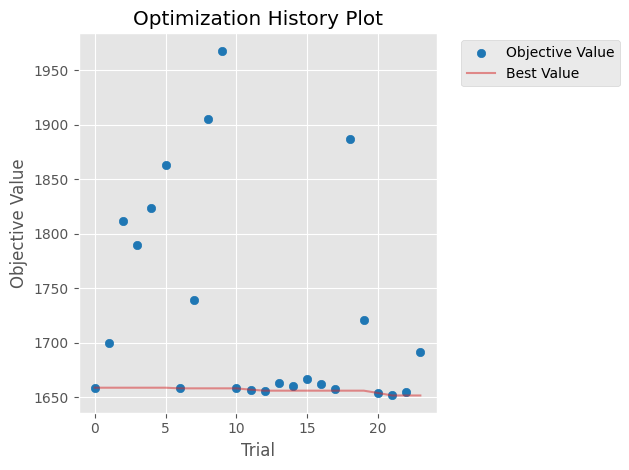

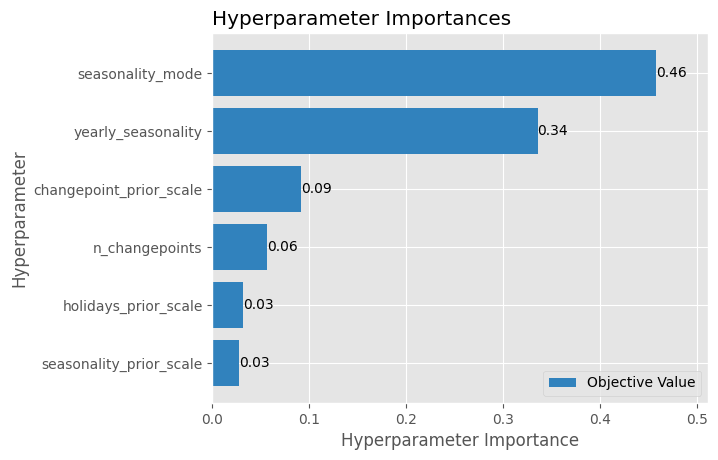

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 24

def sample_params(trial):
    return dict(
        changepoint_prior_scale=trial.suggest_float(
            "changepoint_prior_scale", 0.005, 0.5, log=True),
        seasonality_prior_scale=trial.suggest_float(
            "seasonality_prior_scale", 0.1, 10.0, log=True),
        holidays_prior_scale=trial.suggest_float(
            "holidays_prior_scale", 1.0, 20.0, log=True),
        seasonality_mode=trial.suggest_categorical(
            "seasonality_mode", ["additive", "multiplicative"]),
        yearly_seasonality=trial.suggest_categorical(
            "yearly_seasonality", [6, 10, 20]),
        n_changepoints=trial.suggest_categorical("n_changepoints", [15, 25]))

mlflow.set_experiment("Prophet_Training")
with mlflow.start_run(run_name="Prophet_CV"):
    mlflow.set_tag("stage", "CV")
    mlflow.log_params({"n_trials": N_TRIALS, "search": "optuna_tpe_seed42",
                       "cv_scope": PROPHET_FIXED["cv_scope"]})
    log_table(SAMPLE_COMPOSITION, "cv_sample_composition.csv")

    def objective(trial):
        prophet_params = sample_params(trial)
        cfg = full_config(prophet_params)
        with mlflow.start_run(run_name=f"trial_{trial.number:03d}", nested=True):
            mlflow.log_params({k: str(v) for k, v in cfg.items()})
            metrics = evaluate(lambda: make_pipeline(prophet_params), train_sample)
            mlflow.log_metrics(metrics)
        print(f"trial {trial.number:03d}: wmae_mean={metrics['wmae_mean']:,.0f}")
        return metrics["wmae_mean"]

    study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=N_TRIALS)

    BEST_PROPHET_PARAMS = sample_params(optuna.trial.FixedTrial(study.best_params))
    mlflow.log_metric("best_wmae_mean", study.best_value)
    mlflow.log_params({f"best_{k}": str(v) for k, v in study.best_params.items()})
    try:
        from optuna.visualization.matplotlib import (
            plot_optimization_history, plot_param_importances)
        mlflow.log_figure(plot_optimization_history(study).figure,
                          "cv_optimization_history.png")
        mlflow.log_figure(plot_param_importances(study).figure,
                          "cv_param_importances.png")
    except Exception as e:
        print("optuna plots skipped:", e)

print("best wmae_mean:", round(study.best_value, 1))
print("best params:", study.best_params)

## 6. Stage: `Prophet_Final`

Re-score the winning config with the shared 3-fold CV, retrain it on **all**
training data, and log the whole pipeline as an MLflow pyfunc model. + create submission file

In [ ]:
mlflow.set_experiment("Prophet_Training")
with mlflow.start_run(run_name="Prophet_Final") as final_run:
    mlflow.set_tag("stage", "Final")

    final_cfg = full_config(BEST_PROPHET_PARAMS)
    final_pipe = make_pipeline(BEST_PROPHET_PARAMS).fit(train)
    final_metrics = evaluate(lambda: make_pipeline(BEST_PROPHET_PARAMS), train)
    mlflow.log_params({k: str(v) for k, v in final_cfg.items()})
    mlflow.log_params({("pipe_" + k): str(v)
                       for k, v in final_pipe.get_params().items()})
    mlflow.log_metrics(final_metrics)

    preds = final_pipe.predict(test)
    assert len(preds) == len(test) and not np.isnan(preds).any()
    mlflow.log_metrics({"n_fallback_rows_test": final_pipe.last_fallback_rows_,
                        "n_models_fitted": len(final_pipe.models_),
                        "n_fit_failed": final_pipe.n_fit_failed_,
                        "n_too_short": final_pipe.n_too_short_,
                       })

    with tempfile.TemporaryDirectory() as _td:
        _pipe_dir = Path(_td) / "pipeline"
        final_pipe.save(_pipe_dir)
        mlflow.pyfunc.log_model(
            name="model", python_model=DartsPipelinePyfunc(),
            artifacts={"pipeline_dir": str(_pipe_dir)},
            code_paths=[str(ROOT / "src")],
            input_example=test.head(5))

    sub = pd.DataFrame({
        "Id": test["Store"].astype(str) + "_" + test["Dept"].astype(str)
              + "_" + test["Date"].astype(str),
        "Weekly_Sales": preds,
    })
    (ROOT / "submissions").mkdir(exist_ok=True)
    sub_path = ROOT / "submissions" / "submission_prophet.csv"
    sub.to_csv(sub_path, index=False)
    mlflow.log_artifact(str(sub_path))

print("final CV:", {k: round(v, 1) for k, v in final_metrics.items()})
print("run_id:", final_run.info.run_id)
sub.head()

2026/07/11 23:35:07 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/07/11 23:35:07 INFO mlflow.pyfunc: Inferring model signature from input example
/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64)

2026/07/11 23:36:43 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


🏃 View run Prophet_Final at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/7/runs/2ed01ce410d64a118af1b07482067e9b
🧪 View experiment at: https://dagshub.com/ZukaCS/ML_FINAL_PROJECT.mlflow/#/experiments/7
final CV: {'wmae_fold1': 2145.5, 'wmae_fold2': 1683.0, 'wmae_fold3': 1395.1, 'wmae_mean': 1741.2}
run_id: 2ed01ce410d64a118af1b07482067e9b


,Id,Weekly_Sales
0,1_1_2012-11-02,37616.472459
1,1_1_2012-11-09,24910.428694
2,1_1_2012-11-16,16774.576496
3,1_1_2012-11-23,19490.238540
4,1_1_2012-11-30,24545.717136
